# 19. Validator Multi-Slot (5 Foto: frontal, lateral kanan, lateral kiri, maxillary, mandibular)

Simulasi gerbang upload di app: user diminta upload 5 foto sesuai slotnya masing-masing.
Tiap foto divalidasi dua lapis, pakai aset dari notebook 17 & 18:

1. **Gerbang OOD** (notebook 18) — tolak kalau skor OOD di atas threshold (bukan foto gigi
   valid sama sekali / kualitas terlalu jelek).
2. **Cocok slot** (notebook 17) — kalau lolos OOD, prediksi kelasnya harus sama dengan slot
   yang diharapkan, dan confidence-nya harus di atas ambang minimum.

Kalau salah satu gagal, user diminta upload ulang **khusus slot itu saja**.

In [11]:
import os, json
from glob import glob
import numpy as np
import torch, torch.nn as nn
import copy
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

PROJECT_ROOT = os.path.expanduser('~/IOTN-AC')
MODELS_DIR = os.path.join(PROJECT_ROOT, 'models')
VIEW_CLASSES_5 = ['frontal', 'lateral_kanan', 'lateral_kiri', 'maxillary', 'mandibular']
SLOTS = VIEW_CLASSES_5   # nama slot upload = nama kelas yang diharapkan

PERANGKAT = ('cuda' if torch.cuda.is_available()
             else ('mps' if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available()
                   else 'cpu'))

RATA, SIMPANG = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
tf_eval = transforms.Compose([transforms.Resize((224, 224)),
                              transforms.ToTensor(), transforms.Normalize(RATA, SIMPANG)])

_ckpt5 = os.path.join(MODELS_DIR, 'view5_classifier.pt')
_cfg_path = os.path.join(MODELS_DIR, 'view_ood_config.json')
assert os.path.exists(_ckpt5), f'Model belum ada: {_ckpt5} — jalankan notebook 17 dulu.'
assert os.path.exists(_cfg_path), f'Config OOD belum ada: {_cfg_path} — jalankan notebook 18 dulu.'
print('Perangkat:', PERANGKAT)

Perangkat: mps


## 1. Muat backbone + kepala classifier (notebook 17) dan config OOD (notebook 18)

In [12]:
def buat_resnet_cls(num_classes=len(VIEW_CLASSES_5), dropout=0.3):
    m = models.resnet18(weights=None)
    m.fc = nn.Sequential(nn.Dropout(dropout), nn.Linear(m.fc.in_features, num_classes))
    return m

def pisah_resnet(m):
    mm = copy.deepcopy(m).cpu().eval(); kepala = mm.fc; mm.fc = nn.Identity(); return mm, kepala

_model5 = buat_resnet_cls()
_model5.load_state_dict(torch.load(_ckpt5, map_location='cpu'))
TULANG, KEPALA = pisah_resnet(_model5)
TULANG = TULANG.to(PERANGKAT).eval(); KEPALA = KEPALA.to(PERANGKAT).eval()

with open(_cfg_path) as f:
    _cfg = json.load(f)
CENT = np.array(_cfg['centroid'], dtype=np.float32)
OOD_THRESHOLD = float(_cfg['ood_threshold'])
print(f'Centroid: {CENT.shape} | OOD threshold: {OOD_THRESHOLD:.4f}')

@torch.no_grad()
def embed_satu(path):
    x = tf_eval(Image.open(path).convert('RGB')).unsqueeze(0).to(PERANGKAT)
    f = TULANG(x).cpu().numpy()
    return f / (np.linalg.norm(f, axis=1, keepdims=True) + 1e-9)

def ood_score_satu(path):
    e = embed_satu(path)
    return float(1 - (e @ CENT.T).max())

Centroid: (80, 512) | OOD threshold: 0.1679


## 2. Fungsi validasi inti

`AMBANG_CONFIDENCE`: minimum confidence classifier supaya prediksi kelas dianggap cukup yakin
(walau kelasnya sudah cocok dengan slot). Bisa dilonggarkan kalau ternyata kebanyakan foto
valid ditolak gara-gara ini terlalu ketat.

In [13]:
AMBANG_CONFIDENCE = 0.5

def validasi_satu_foto(path, kelas_diharapkan, ambang_confidence=AMBANG_CONFIDENCE):
    """Kembalikan dict berisi status lolos/tidak + detail alasan."""
    if not os.path.exists(path):
        return dict(lolos=False, alasan='file_tidak_ada', pred_kelas=None, confidence=None,
                    skor_ood=None, pesan=f'File tidak ditemukan: {path}')

    skor = ood_score_satu(path)
    if skor > OOD_THRESHOLD:
        return dict(lolos=False, alasan='ood_ditolak', pred_kelas='lainnya', confidence=None,
                    skor_ood=skor,
                    pesan=f'Foto ini terdeteksi "lainnya" (skor OOD {skor:.4f} > {OOD_THRESHOLD:.4f}) '
                          f'— bukan foto gigi yang valid.')

    with torch.no_grad():
        x = tf_eval(Image.open(path).convert('RGB')).unsqueeze(0).to(PERANGKAT)
        prob = torch.softmax(KEPALA(TULANG(x)), 1).cpu().numpy()[0]
    pred_i = int(prob.argmax()); pred_kelas = VIEW_CLASSES_5[pred_i]; conf = float(prob[pred_i])

    if pred_kelas != kelas_diharapkan:
        return dict(lolos=False, alasan='salah_slot', pred_kelas=pred_kelas, confidence=conf,
                    skor_ood=skor,
                    pesan=f'Slot ini seharusnya "{kelas_diharapkan}", tapi foto terdeteksi sebagai '
                          f'"{pred_kelas}" ({conf:.1%}). Kemungkinan foto tertukar slot.')

    if conf < ambang_confidence:
        return dict(lolos=False, alasan='confidence_rendah', pred_kelas=pred_kelas, confidence=conf,
                    skor_ood=skor,
                    pesan=f'Kelas terdeteksi sudah benar ("{pred_kelas}") tapi confidence cuma {conf:.1%} '
                          f'(ambang {ambang_confidence:.0%}) — foto kurang jelas/ragu, coba foto lain.')

    return dict(lolos=True, alasan='ok', pred_kelas=pred_kelas, confidence=conf, skor_ood=skor,
                pesan=f'OK — "{pred_kelas}" cocok slot, confidence {conf:.1%}.')

## 3. Validasi 5 slot sekaligus (non-interaktif)

Untuk uji cepat dengan path yang sudah disiapkan sekaligus (tanpa `input()`).

In [14]:
def validasi_5_slot(path_per_slot):
    """path_per_slot: dict {nama_slot: path_foto}. Kembalikan dict hasil per slot."""
    hasil = {}
    for slot in SLOTS:
        path = path_per_slot.get(slot)
        if path is None:
            hasil[slot] = dict(lolos=False, alasan='tidak_diisi', pesan='Slot belum diisi.')
            continue
        hasil[slot] = validasi_satu_foto(path, slot)
    return hasil

def cetak_hasil_validasi(hasil):
    print(f'{"slot":16s} {"status":8s} {"terdeteksi":16s} {"conf":>6s}  pesan')
    print('-' * 100)
    for slot, r in hasil.items():
        status = 'LOLOS' if r['lolos'] else 'DITOLAK'
        conf_s = f'{r["confidence"]:.0%}' if r.get('confidence') is not None else '-'
        print(f'{slot:16s} {status:8s} {str(r.get("pred_kelas")):16s} {conf_s:>6s}  {r["pesan"]}')

# --- CONTOH PAKAI: ganti path di bawah untuk uji cepat 5 foto sekaligus ---
CONTOH_PATH = {
    'frontal': '/ganti/dengan/path/foto_frontal.jpg',
    'lateral_kanan': '/ganti/dengan/path/foto_lateral_kanan.jpg',
    'lateral_kiri': '/ganti/dengan/path/foto_lateral_kiri.jpg',
    'maxillary': '/ganti/dengan/path/foto_maxillary.jpg',
    'mandibular': '/ganti/dengan/path/foto_mandibular.jpg',
}
HASIL_CONTOH = validasi_5_slot(CONTOH_PATH)
cetak_hasil_validasi(HASIL_CONTOH)

slot             status   terdeteksi         conf  pesan
----------------------------------------------------------------------------------------------------
frontal          DITOLAK  None                  -  File tidak ditemukan: /ganti/dengan/path/foto_frontal.jpg
lateral_kanan    DITOLAK  None                  -  File tidak ditemukan: /ganti/dengan/path/foto_lateral_kanan.jpg
lateral_kiri     DITOLAK  None                  -  File tidak ditemukan: /ganti/dengan/path/foto_lateral_kiri.jpg
maxillary        DITOLAK  None                  -  File tidak ditemukan: /ganti/dengan/path/foto_maxillary.jpg
mandibular       DITOLAK  None                  -  File tidak ditemukan: /ganti/dengan/path/foto_mandibular.jpg


## 4. Mode interaktif — minta upload ulang khusus slot yang gagal

Untuk tiap slot, minta path foto lewat `input()`, validasi langsung, kalau gagal cetak
alasannya dan minta path baru **hanya untuk slot itu** — slot lain yang sudah lolos tidak
perlu diulang.

In [15]:
def input_interaktif_5_foto(maks_percobaan=5):
    hasil_final = {}
    for slot in SLOTS:
        print(f'\n=== Slot: {slot} ===')
        percobaan = 0
        while True:
            percobaan += 1
            path = input(f'Masukkan path foto untuk "{slot}": ').strip()
            r = validasi_satu_foto(path, slot)
            print(' ', r['pesan'])
            if r['lolos']:
                hasil_final[slot] = dict(path=path, **r)
                break
            if percobaan >= maks_percobaan:
                print(f'  Sudah {maks_percobaan}x gagal untuk slot "{slot}", dilewati dulu — bisa diulang manual nanti.')
                hasil_final[slot] = dict(path=None, **r)
                break

    print('\n=== Ringkasan akhir ===')
    for slot, r in hasil_final.items():
        tanda = 'OK' if r['lolos'] else 'BELUM LOLOS'
        print(f'  {slot:16s}: {tanda}  ({r["path"]})')
    return hasil_final

# jalankan baris di bawah untuk mulai sesi input interaktif:
HASIL = input_interaktif_5_foto()


=== Slot: frontal ===
  OK — "frontal" cocok slot, confidence 99.5%.

=== Slot: lateral_kanan ===
  Slot ini seharusnya "lateral_kanan", tapi foto terdeteksi sebagai "lateral_kiri" (95.1%). Kemungkinan foto tertukar slot.
  Slot ini seharusnya "lateral_kanan", tapi foto terdeteksi sebagai "lateral_kiri" (71.7%). Kemungkinan foto tertukar slot.
  Slot ini seharusnya "lateral_kanan", tapi foto terdeteksi sebagai "lateral_kiri" (53.8%). Kemungkinan foto tertukar slot.
  OK — "lateral_kanan" cocok slot, confidence 81.1%.

=== Slot: lateral_kiri ===
  OK — "lateral_kiri" cocok slot, confidence 88.5%.

=== Slot: maxillary ===
  OK — "maxillary" cocok slot, confidence 72.9%.

=== Slot: mandibular ===
  OK — "mandibular" cocok slot, confidence 82.6%.

=== Ringkasan akhir ===
  frontal         : OK  (/Users/rdrusdiati/IOTN-AC/data/view5/test/frontal/201817201906171.JPG)
  lateral_kanan   : OK  (/Users/rdrusdiati/IOTN-AC/data/view5/test/lateral_kanan/201870201808312.JPG)
  lateral_kiri    : OK 

## 5. Tampilkan 5 foto yang lolos berdampingan (opsional, setelah validasi selesai)

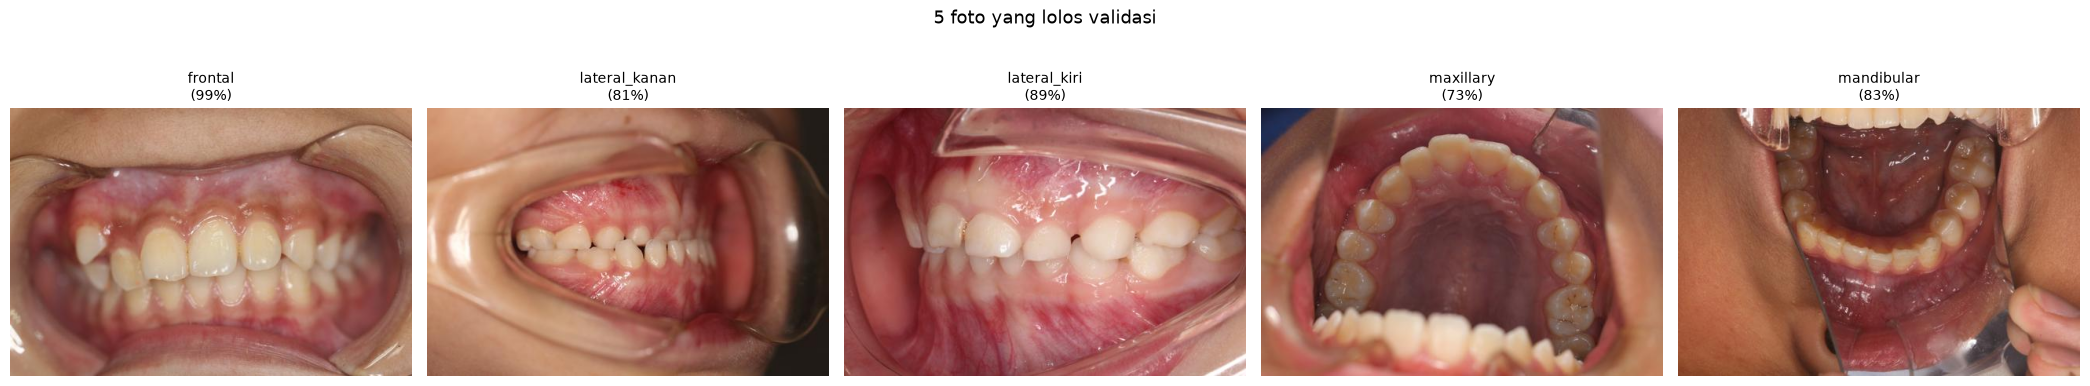

In [16]:
def tampilkan_hasil(hasil_final):
    lolos = {s: r for s, r in hasil_final.items() if r.get('lolos') and r.get('path')}
    if not lolos:
        print('Belum ada slot yang lolos untuk ditampilkan.'); return
    fig, axes = plt.subplots(1, len(lolos), figsize=(4.2 * len(lolos), 4.5))
    if len(lolos) == 1: axes = [axes]
    for ax, (slot, r) in zip(axes, lolos.items()):
        img = Image.open(r['path']).convert('RGB')
        ax.imshow(img); ax.axis('off')
        ax.set_title(f'{slot}\n({r["confidence"]:.0%})', fontsize=10)
    fig.suptitle('5 foto yang lolos validasi', fontsize=13)
    plt.tight_layout(); plt.show()

tampilkan_hasil(HASIL)

## Catatan

- Logic per-slot ini (OOD gate -> cocok kelas -> ambang confidence) adalah blueprint untuk
  diimplementasikan di app iOS sebagai gerbang sebelum foto diterima ke pipeline DHC/AC/3D.
- Kalau nanti hasil evaluasi notebook 18 menunjukkan OOD kurang menangkap near-miss dengan
  baik, `validasi_satu_foto` di sini tinggal ditambah lapis classifier hybrid tanpa mengubah
  struktur alur validasi 5-slot yang sudah ada.

## Langkah lanjutan (belum di notebook ini)

- **Kelas ke-6 "lainnya"** (bukan foto gigi valid / near-miss) — retrain jadi 6-kelas setelah
  data negatif terkumpul.
- **Ekspor Core ML** — bungkus dengan normalisasi tertanam + `ct.convert`, mengikuti pola
  persis seperti `ACGraderCoreML` di notebook 10, lalu jadi gerbang sebelum DHC/AC/3D model di app.